
[notice] A new release of pip is available: 26.0.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


[fetch_atlas_schaefer_2018] Dataset directory found: C:\Users\aadip\nilearn_data\schaefer_2018
Number of regions: 101
Timecourse shape: (300, 100)
Subjects to process: 53
[1/53] sub-001 done
[2/53] sub-002 done
[3/53] sub-003 done
[4/53] sub-004 done
[5/53] sub-005 done
[6/53] sub-006 done
[7/53] sub-007 done
[8/53] sub-008 done
[9/53] sub-009 done
[10/53] sub-010 done
[11/53] sub-011 done
[12/53] sub-012 done
[13/53] sub-013 done


C:\Users\aadip\AppData\Local\Temp\ipykernel_33728\3440288555.py:50: UserWarning: After resampling the label image to the data image, the following labels were removed: {np.float32(32.0), np.float32(80.0)}. Label image only contains 99 labels (including background).
  tc = masker.fit_transform(func_file)


[14/53] sub-014 SKIPPED — only 98 regions
[15/53] sub-015 done


C:\Users\aadip\AppData\Local\Temp\ipykernel_33728\3440288555.py:50: UserWarning: After resampling the label image to the data image, the following labels were removed: {np.float32(32.0), np.float32(80.0), np.float32(51.0), np.float32(31.0)}. Label image only contains 97 labels (including background).
  tc = masker.fit_transform(func_file)


[16/53] sub-016 SKIPPED — only 96 regions
[17/53] sub-017 done
[18/53] sub-018 done
[19/53] sub-019 done
[20/53] sub-020 done


C:\Users\aadip\AppData\Local\Temp\ipykernel_33728\3440288555.py:50: UserWarning: After resampling the label image to the data image, the following labels were removed: {np.float32(32.0), np.float32(80.0)}. Label image only contains 99 labels (including background).
  tc = masker.fit_transform(func_file)


[21/53] sub-021 SKIPPED — only 98 regions
[22/53] sub-022 done
[23/53] sub-023 done
[24/53] sub-024 done
[25/53] sub-025 done
[26/53] sub-026 done
[27/53] sub-027 done
[28/53] sub-028 done
[29/53] sub-029 done
[30/53] sub-030 done
[31/53] sub-031 done
[32/53] sub-032 done
[33/53] sub-033 done
[34/53] sub-034 done
[35/53] sub-035 done
[36/53] sub-036 done
[37/53] sub-037 done
[38/53] sub-038 done
[39/53] sub-039 done
[40/53] sub-040 done


C:\Users\aadip\AppData\Local\Temp\ipykernel_33728\3440288555.py:50: UserWarning: After resampling the label image to the data image, the following labels were removed: {np.float32(32.0), np.float32(80.0)}. Label image only contains 99 labels (including background).
  tc = masker.fit_transform(func_file)


[41/53] sub-041 SKIPPED — only 98 regions
[42/53] sub-042 done
[43/53] sub-043 done
[44/53] sub-045 done
[45/53] sub-046 done
[46/53] sub-047 done
[47/53] sub-048 done
[48/53] sub-049 done
[49/53] sub-050 done
[50/53] sub-051 done
[51/53] sub-052 done
[52/53] sub-053 done
[53/53] sub-054 done

Feature matrix X shape: (49, 4950)
Skipped subjects: ['sub-014', 'sub-016', 'sub-021', 'sub-041']
X shape: (49, 4950)
y shape: (49,)
Counts: {np.str_('F'): 23, np.str_('M'): 26}
Fold accuracies: [0.8        0.8        0.8        0.7        0.66666667]
Mean accuracy: 0.7533333333333334
1. region 75 <-> region 95  (weight -0.032)
2. region 76 <-> region 80  (weight 0.027)
3. region 76 <-> region 81  (weight 0.027)
4. region 2 <-> region 12  (weight 0.027)
5. region 67 <-> region 92  (weight -0.026)
6. region 43 <-> region 59  (weight -0.025)
7. region 1 <-> region 52  (weight 0.025)
8. region 39 <-> region 52  (weight 0.025)
9. region 37 <-> region 60  (weight 0.025)
10. region 9 <-> region 76  (we

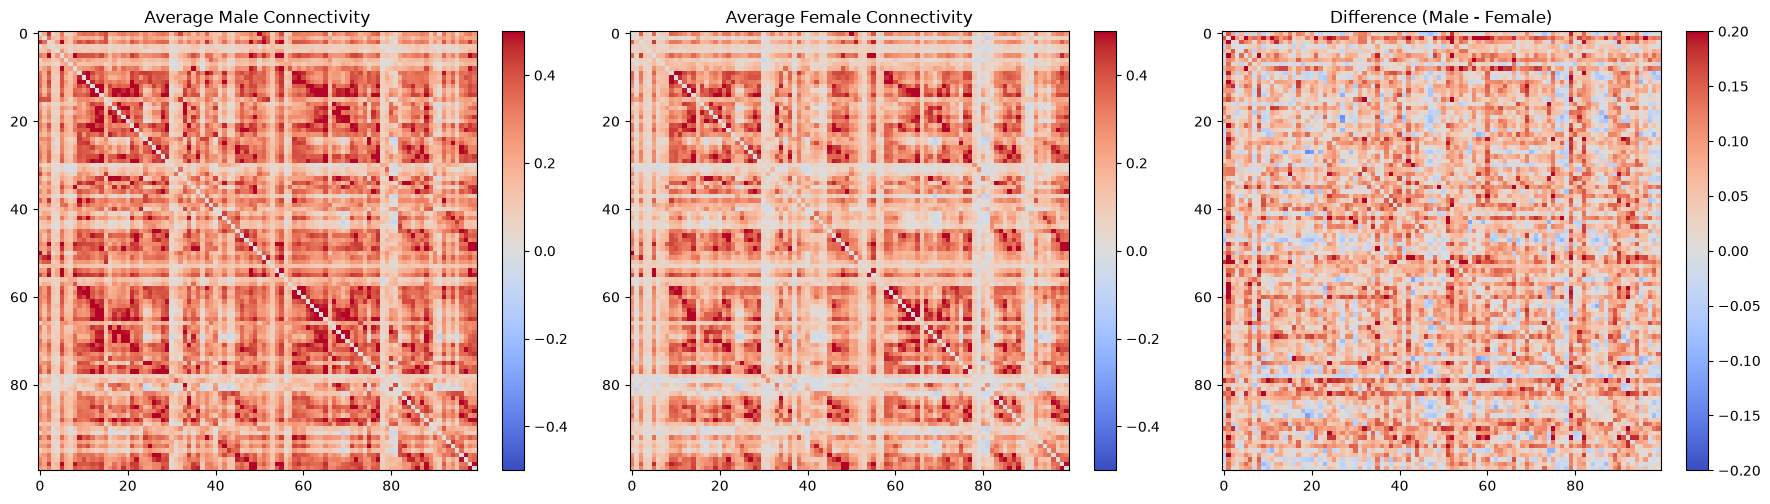

Fold accuracies: [0.8        0.8        0.8        0.7        0.66666667]
Mean accuracy: 0.7533333333333334
Real accuracy: 0.753
Permutation test score: 0.508
p-value: 0.0030
[fetch_atlas_schaefer_2018] Dataset directory found: C:\Users\aadip\nilearn_data\schaefer_2018
Coordinates shape: (100, 3)


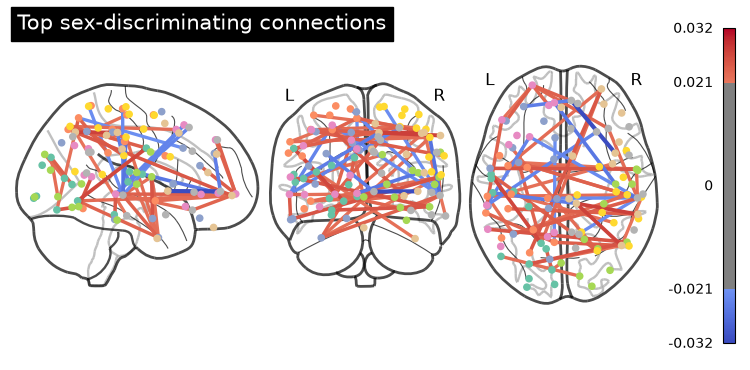

In [4]:
from matplotlib.patches import bbox_artist
!pip install nilearn scikit-learn matplotlib

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from nilearn import datasets, plotting
from nilearn.maskers import NiftiLabelsMasker
from nilearn.connectome import ConnectivityMeasure
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score, StratifiedKFold, permutation_test_score
from collections import Counter
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif


dataset_path = r"C:\Users\aadip\Downloads\OCD Dataset"
schaefer = datasets.fetch_atlas_schaefer_2018(n_rois=100)
print("Number of regions:", len(schaefer.labels))

masker = NiftiLabelsMasker(
    labels_img=schaefer.maps,
    standardize="zscore_sample",
    detrend=True,
    low_pass=0.08,
    high_pass=0.01,
    t_r=2.0,
)

sub = "sub-001"
func_file = os.path.join(dataset_path, sub, "func", f"{sub}_task-rest_bold.nii.gz")
timecourses = masker.fit_transform(func_file)
print("Timecourse shape:", timecourses.shape)

# Build the subject list (excludes sub-044 and any missing files)
subjects = []
for sub_name in sorted(os.listdir(dataset_path)):
    if sub_name.startswith("sub-"):
        f = os.path.join(dataset_path, sub_name, "func", f"{sub_name}_task-rest_bold.nii.gz")
        if os.path.exists(f):
            subjects.append(sub_name)
print("Subjects to process:", len(subjects))   # should be 53

feature_rows = []
kept_subjects = []
skipped = []
for i, sub in enumerate(subjects):
    func_file = os.path.join(dataset_path, sub, "func", f"{sub}_task-rest_bold.nii.gz")
    tc = masker.fit_transform(func_file)

    # Guard: only accept subjects with the full 100 regions
    if tc.shape[1] != 100:
        print(f"[{i+1}/{len(subjects)}] {sub} SKIPPED — only {tc.shape[1]} regions")
        skipped.append(sub)
        continue

    # fresh measure per subject avoids the locked-feature-count problem
    cm = ConnectivityMeasure(kind="correlation", standardize=False)
    conn = cm.fit_transform([tc])[0]
    iu = np.triu_indices_from(conn, k=1)
    feature_rows.append(conn[iu])
    kept_subjects.append(sub)
    print(f"[{i+1}/{len(subjects)}] {sub} done")

X = np.array(feature_rows)
print("\nFeature matrix X shape:", X.shape)
print("Skipped subjects:", skipped)

participants = pd.read_csv(os.path.join(dataset_path, "participants.tsv"), sep="\t")
sex_lookup = dict(zip(participants["participant_id"], participants["sex"]))

# CRITICAL: build y from the SAME subjects that made it into X
y = np.array([sex_lookup[sub] for sub in kept_subjects])

print("X shape:", X.shape)   # (49, 4950)
print("y shape:", y.shape)   # must be (49,)
print("Counts:", {v: list(y).count(v) for v in set(y)})

clf = SVC(kernel="linear")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(clf, X, y, cv=cv)

print("Fold accuracies:", scores)
print("Mean accuracy:", scores.mean())

clf.fit(X, y)
weights = clf.coef_[0]
top_idx = np.argsort(np.abs(weights))[-10:][::-1]

iu = np.triu_indices(100, k=1)
for rank, idx in enumerate(top_idx, 1):
    r1, r2 = iu[0][idx], iu[1][idx]
    print(f"{rank}. region {r1} <-> region {r2}  (weight {weights[idx]:.3f})")

labels = schaefer.labels

pairs = [(75,95),(76,80),(76,81),(76,82),(2,12),(67,92),(43,59),(1,52),(39,52),(37,60),(9,76)]

for r1, r2 in pairs:
    name1 = labels[r1 + 1].decode() if isinstance(labels[r1 + 1], bytes) else labels[r1 + 1]
    name2 = labels[r2 + 1].decode() if isinstance(labels[r2 + 1], bytes) else labels[r2 + 1]
    print(f"{r1} <--> {r2}: {name1} <--> {name2}")

def network_of(region_idx):
    name = schaefer.labels[region_idx + 1]
    if isinstance(name, bytes):
        name = name.decode()
    return name.split("_")[2]

counts = Counter()
for r1, r2 in pairs:
    counts[network_of(r1)] += 1
    counts[network_of(r2)] += 1

print("Network appearances across top connections:")
for net, n in counts.most_common():
    print(f" {net}: {n}")

all_networks = []
for i in range(1, 101):
    name = schaefer.labels[i]
    if isinstance(name, bytes):
        name = name.decode()
    all_networks.append(name.split("_")[2])

network_sizes = Counter(all_networks)
print("Regions per network:", dict(network_sizes))
observed = dict(counts)
total_regions = 100
total_endpoints = sum(observed.values())

print("\nNetwork| observed | expected-by-chance | ratio(obs/exp)")
for net in network_sizes:
    exp = total_endpoints * (network_sizes[net] / total_regions)
    obs = observed.get(net, 0)
    ratio = obs / exp if exp > 0 else 0
    print(f"{net:14s} {obs:5d} {exp:8.1f} {ratio:.2f}")

def unflatten(row, n=100):
    mat = np.zeros((n, n))
    iu = np.triu_indices(n, k=1)
    mat[iu] = row
    mat = mat + mat.T
    return mat

male_avg = np.mean([unflatten(X[i]) for i in range(len(y)) if y[i] == "M"], axis=0)
female_avg = np.mean([unflatten(X[i]) for i in range(len(y)) if y[i] == "F"], axis=0)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

im0 = axes[0].imshow(male_avg, cmap="coolwarm", vmin=-0.5, vmax=0.5)
axes[0].set_title("Average Male Connectivity")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(female_avg, cmap="coolwarm", vmin=-0.5, vmax=0.5)
axes[1].set_title("Average Female Connectivity")
plt.colorbar(im1, ax=axes[1], fraction=0.046)

diff = male_avg - female_avg
im2 = axes[2].imshow(diff, cmap="coolwarm", vmin=-0.2, vmax=0.2)
axes[2].set_title("Difference (Male - Female)")
plt.colorbar(im2, ax=axes[2], fraction=0.046)

plt.tight_layout()
plt.savefig("difference_map.png", dpi=150, bbox_inches="tight")
plt.show()

pipe = Pipeline([
    ("select", SelectKBest(f_classif, k=4900)),
    ("svm", SVC(kernel="linear")),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(pipe, X, y, cv=cv)

print("Fold accuracies:", scores)
print("Mean accuracy:", scores.mean())

clf = SVC(kernel="linear", random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

score, perm_scores, pvalue = permutation_test_score(
    clf, X, y, cv=cv, n_permutations=1000, scoring="accuracy", random_state=42
)

print(f"Real accuracy: {score:.3f}")
print(f"Permutation test score: {perm_scores.mean():.3f}")
print(f"p-value: {pvalue:.4f}")

schaefer = datasets.fetch_atlas_schaefer_2018(n_rois=100)
masker = NiftiLabelsMasker(labels_img=schaefer.maps)
masker.fit()
coords = plotting.find_parcellation_cut_coords(schaefer.maps)
print("Coordinates shape:", coords.shape)

clf.fit(X, y)
weights = clf.coef_[0]
weight_matrix = np.zeros((100, 100))
iu = np.triu_indices(100, k=1)
weight_matrix[iu] = weights
weight_matrix = weight_matrix + weight_matrix.T

threshold = np.percentile(np.abs(weights), 99)

display = plotting.plot_connectome(
    weight_matrix,
    coords,
    edge_threshold=threshold,
    node_size=20,
    edge_cmap="coolwarm",
    title="Top sex-discriminating connections"
)
display.savefig("connectome.png", dpi=150)
plotting.show()